# **การเตรียมข้อมูลและสร้าง Features**

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc
warnings.filterwarnings('ignore')

# 🎨 ตั้งค่าธีม Hacker/Cyberpunk ให้กราฟสวยงาม
plt.style.use('dark_background')
import matplotlib as mpl
mpl.rcParams['figure.facecolor'] = '#0b0c10'
mpl.rcParams['axes.facecolor'] = '#0b0c10'
mpl.rcParams['grid.color'] = '#1f2833'
mpl.rcParams['text.color'] = '#c5c6c7'

# 1. โหลดข้อมูล (แก้ชื่อไฟล์ให้ตรงกับของคุณ)
print("Loading file: btcusd_1-min_data.csv")
df = pd.read_csv('btcusd_1-min_data.csv')

# 2. ปรับชื่อคอลัมน์ให้อ่านง่าย (Universal Column Renamer)
col_map = {}
for c in df.columns:
    clower = c.lower()
    if 'timestamp' in clower or 'date' in clower: col_map[c] = 'Timestamp'
    elif 'open' in clower and 'open' not in col_map.values(): col_map[c] = 'Open'
    elif 'high' in clower and 'high' not in col_map.values(): col_map[c] = 'High'
    elif 'low' in clower and 'low' not in col_map.values(): col_map[c] = 'Low'
    elif 'close' in clower and 'close' not in col_map.values(): col_map[c] = 'Close'
    elif 'volume' in clower and 'Volume' not in col_map.values(): col_map[c] = 'Volume'
df.rename(columns=col_map, inplace=True)

# 3. จัดการ Timestamp และแปลงเป็นรายวัน (Daily Resample)
df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s', errors='coerce')
df.dropna(subset=['Timestamp', 'Close'], inplace=True)
df.set_index('Timestamp', inplace=True)

agg_dict = {'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last', 'Volume': 'sum'}
df_daily = df.resample('D').agg(agg_dict).dropna()
print("✅ เตรียมข้อมูลรายวันสำเร็จ! Shape:", df_daily.shape)

Loading file: btcusd_1-min_data.csv
✅ เตรียมข้อมูลรายวันสำเร็จ! Shape: (5176, 5)


In [7]:
# Universal Column Renamer to match our logic
col_map = {}
for c in df.columns:
    clower = c.lower()
    if 'timestamp' in clower or 'date' in clower: col_map[c] = 'Timestamp'
    elif 'open' in clower and 'open' not in col_map.values(): col_map[c] = 'Open'
    elif 'high' in clower and 'high' not in col_map.values(): col_map[c] = 'High'
    elif 'low' in clower and 'low' not in col_map.values(): col_map[c] = 'Low'
    elif 'close' in clower and 'close' not in col_map.values(): col_map[c] = 'Close'
    elif 'volume' in clower and 'Volume' not in col_map.values(): col_map[c] = 'Volume'

df.rename(columns=col_map, inplace=True)
print("Mapped columns:", df.columns)

# Preprocessing: Convert Timestamp and Drop NaNs
if 'Timestamp' in df.columns:
    # if it smells like unix time
    if df['Timestamp'].dtype in [np.int64, np.float64, int, float] and df['Timestamp'].max() > 1e10:
        # usually milliseconds not seconds if >1e10 for typical years
        pass
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s', errors='coerce')
    # fallback to normal datetime parser if unit='s' results in NaT largely
    if df['Timestamp'].isna().sum() > len(df) * 0.5:
        df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    df.set_index('Timestamp', inplace=True)

# Drop rows where the closing price is missing
if 'Close' in df.columns:
    df.dropna(subset=['Close'], inplace=True)

# Ensure numeric
for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Due to the massive size (minute-level), let's resample the data to DAILY frequency for macro analysis
agg_dict = {}
if 'Open' in df.columns: agg_dict['Open'] = 'first'
if 'High' in df.columns: agg_dict['High'] = 'max'
if 'Low' in df.columns: agg_dict['Low'] = 'min'
if 'Close' in df.columns: agg_dict['Close'] = 'last'
if 'Volume' in df.columns: agg_dict['Volume'] = 'sum'

df_daily = df.resample('D').agg(agg_dict)

print("Aggregated Daily Data Shape:", df_daily.shape)
df_daily.tail()

Mapped columns: Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')
Aggregated Daily Data Shape: (5176, 5)


,Open,High,Low,Close,Volume
Timestamp,,,,,
2026-02-27,67488.0,68207.0,64935.0,65868.0,4056.206406
2026-02-28,65868.0,67743.0,63037.0,66985.0,5941.593083
2026-03-01,66982.0,68201.0,65051.0,65771.0,4640.412517
2026-03-02,65776.0,70111.0,65259.0,68821.0,6481.124681
2026-03-03,68821.0,68847.0,68793.0,68795.0,2.451376


# **EDA: วิเคราะห์ข้อมูลเบื้องต้น**

### 1. การตรวจสอบและจัดการ Missing Values (Handling Missing Values)
ก่อนนำข้อมูลไปใช้งาน เราต้องตรวจสอบความสมบูรณ์ของข้อมูลก่อน
**เหตุผลในการจัดการ:** ข้อมูลประเภท Time Series ที่มีการคำนวณ Technical Indicators (เช่น SMA 50 วัน หรือ RSI 14 วัน) จะทำให้เกิดค่าว่าง (NaN) ในช่วงวันแรกๆ ของชุดข้อมูลโดยอัตโนมัติ เนื่องจากยังไม่มีข้อมูลย้อนหลังมากพอให้คำนวณ การเติมค่า (Imputation) ด้วยค่าเฉลี่ยหรือค่า 0 จะทำให้สัญญาณทางเทคนิคผิดเพี้ยน **วิธีที่สมเหตุสมผลที่สุดในกรณีนี้คือการ Drop แถวที่มีค่า NaN ทิ้งไป (dropna)** เพื่อให้โมเดลได้เรียนรู้จากสัญญาณที่ถูกต้อง 100%

🔍 จำนวน Missing Values ก่อนจัดการ:
Open            0
High            0
Low             0
Close           0
Volume          0
SMA_50          0
SMA_200         0
Daily_Return    0
RSI_14          0
MACD            0
Volatility      0
Target          0
dtype: int64


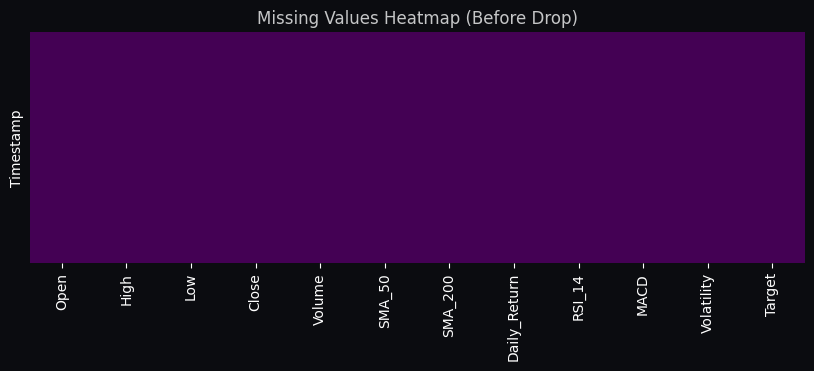


 จัดการ Missing Values เรียบร้อย! จำนวนข้อมูลที่พร้อมใช้งาน: 4977 แถว


In [15]:
# 1. เช็คจำนวน Missing Values ก่อนจัดการ
print("🔍 จำนวน Missing Values ก่อนจัดการ:")
print(df_daily.isnull().sum())

# สร้าง Heatmap ให้เห็นภาพชัดเจน (ถ้ามีช่องโหว่จะเห็นเป็นสีเหลือง)
plt.figure(figsize=(10, 3))
sns.heatmap(df_daily.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap (Before Drop)')
plt.show()

# 2. จัดการด้วยการ Dropna ตามเหตุผลที่อธิบายไว้
df_daily.dropna(inplace=True)

print(f"\n จัดการ Missing Values เรียบร้อย! จำนวนข้อมูลที่พร้อมใช้งาน: {df_daily.shape[0]} แถว")

### 2. การวิเคราะห์การกระจายตัวของข้อมูล (Feature Distributions Analysis)
การดู Distribution ของแต่ละ Feature ช่วยให้เราเข้าใจพฤติกรรมของตลาดและดูว่ามี Outliers รุนแรงหรือไม่:
* **Daily Return:** ดูการแกว่งตัวของกำไร/ขาดทุนรายวัน (มักจะมีการกระจายตัวคล้ายระฆังคว่ำ แต่มีหางยาว - Fat Tails)
* **Volatility:** ดูระดับความผันผวน
* **Volume:** ปริมาณการซื้อขายมักจะเบ้ขวา (Right-skewed) คือวันปกติเทรดน้อย แต่วันที่ตลาดตื่นตระหนกจะเทรดพุ่งสูงปรี๊ด
* **RSI_14:** ดูว่าตลาดแกว่งอยู่ในโซนปกติ หรือมักจะเทไปทาง Overbought/Oversold

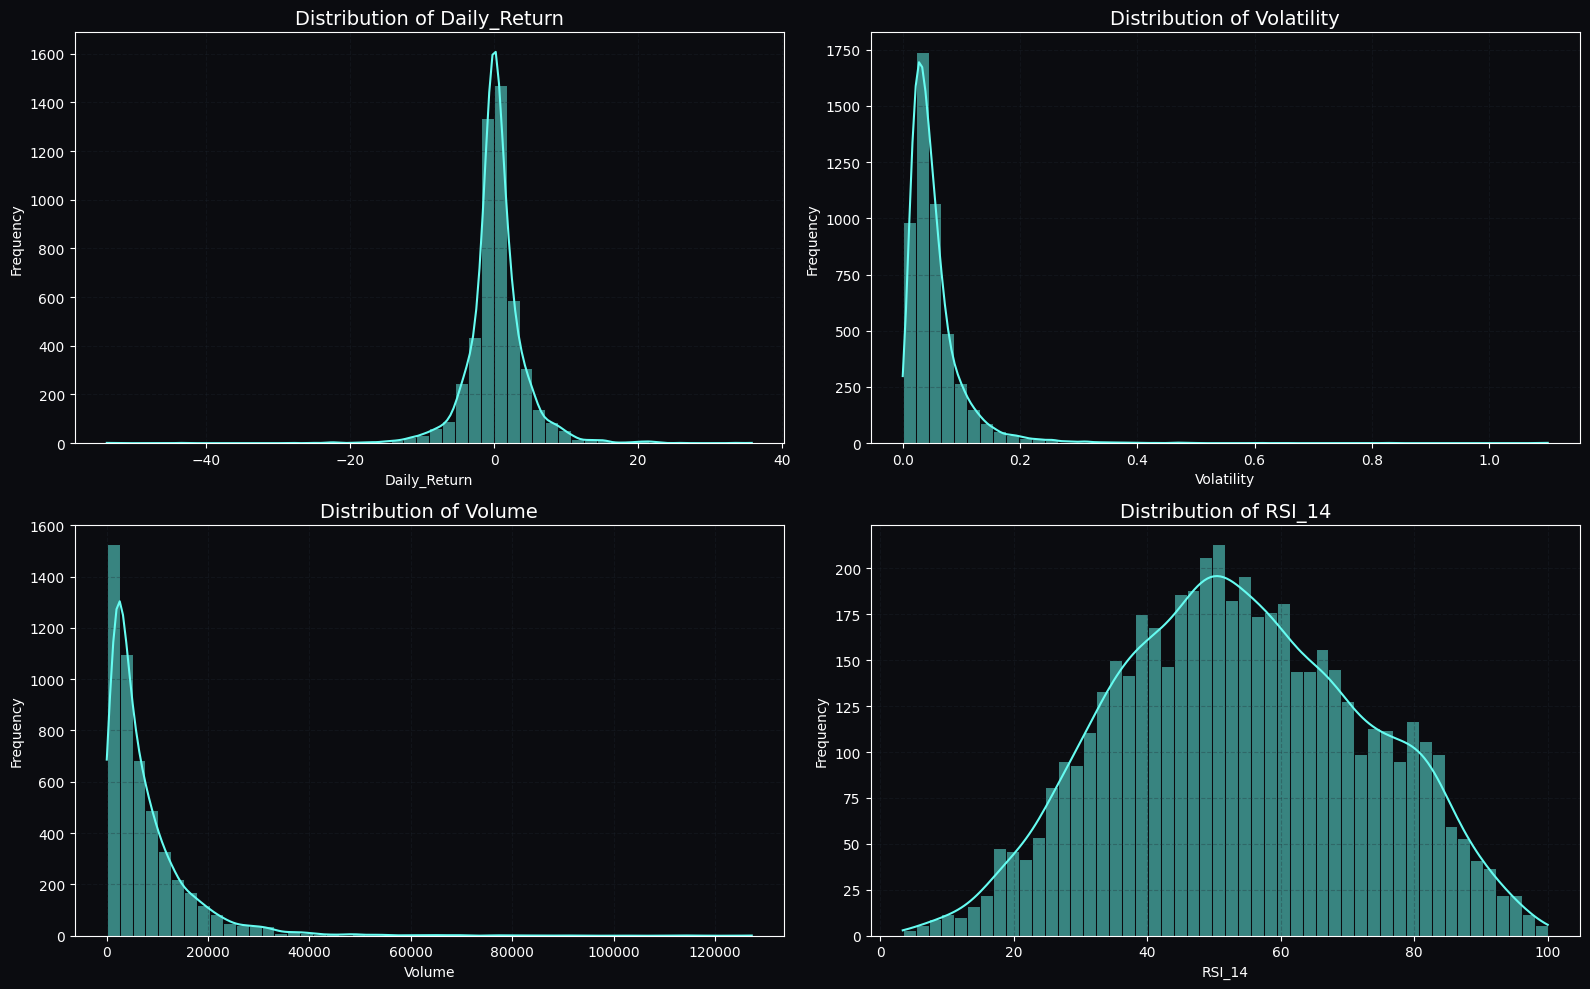

In [16]:
# เลือก Features หลักๆ มาพล็อตดู Distribution
features_to_plot = ['Daily_Return', 'Volatility', 'Volume', 'RSI_14']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.histplot(df_daily[col], bins=50, kde=True, ax=axes[i], color='#66fcf1', edgecolor='#0b0c10')
    axes[i].set_title(f'Distribution of {col}', fontsize=14, color='white')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

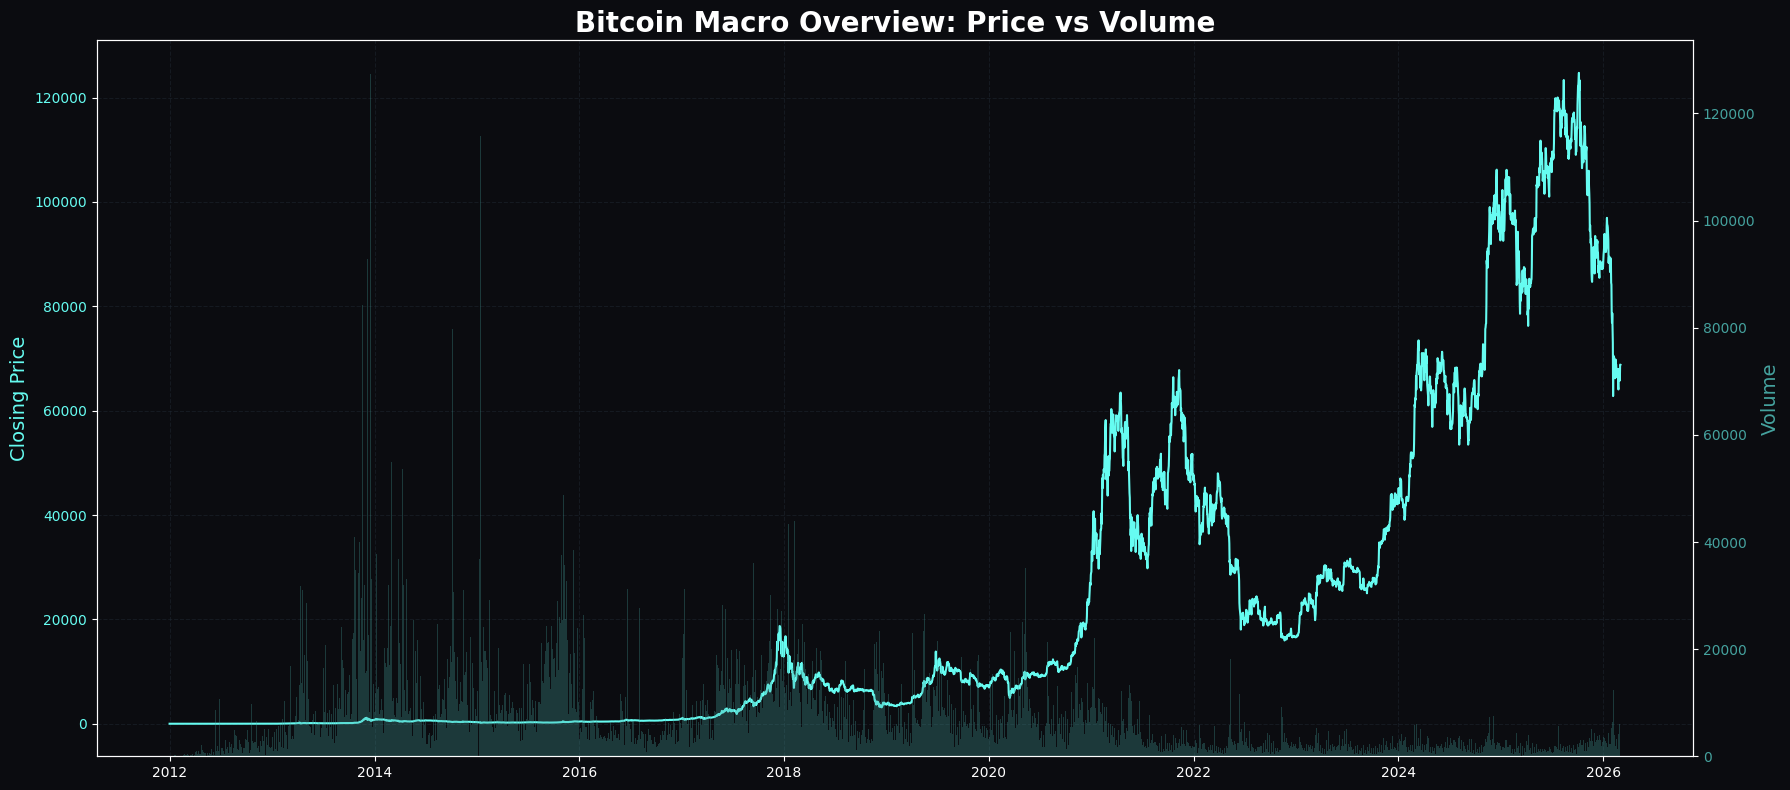

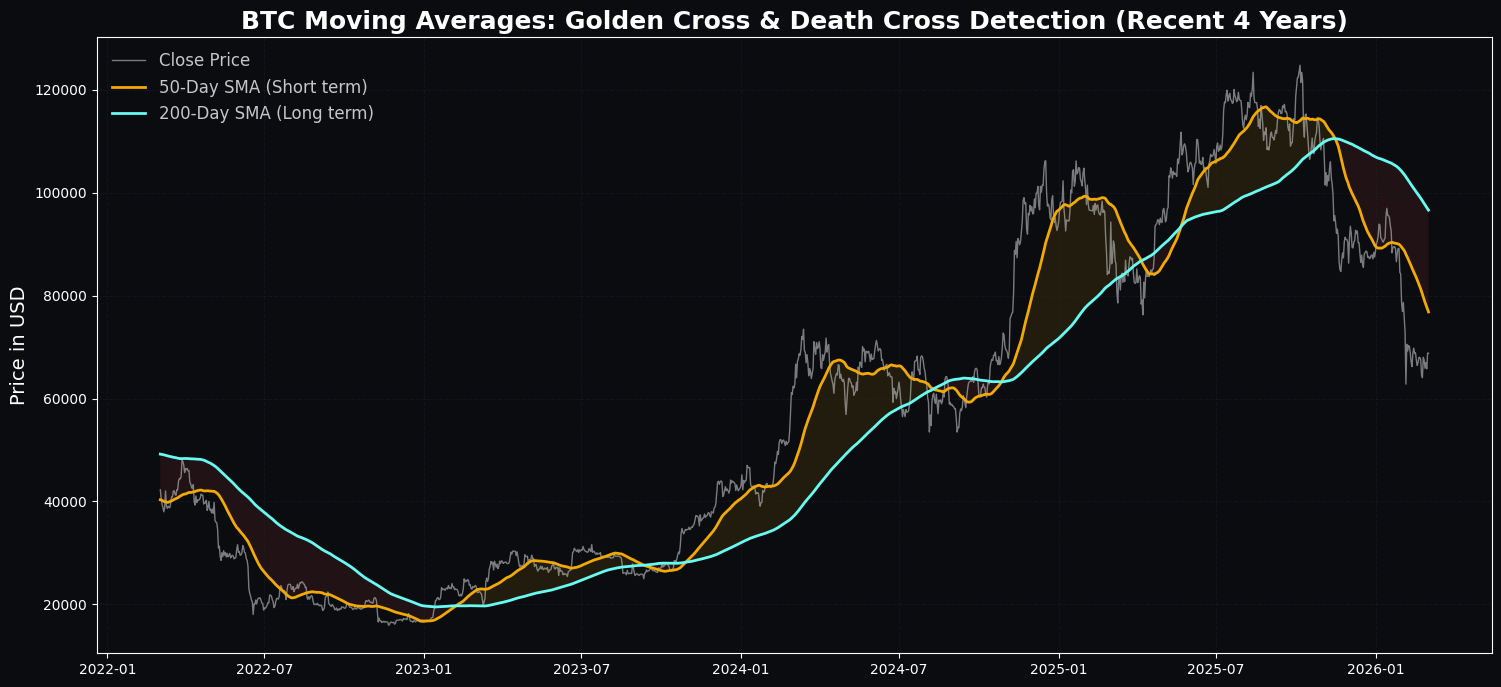

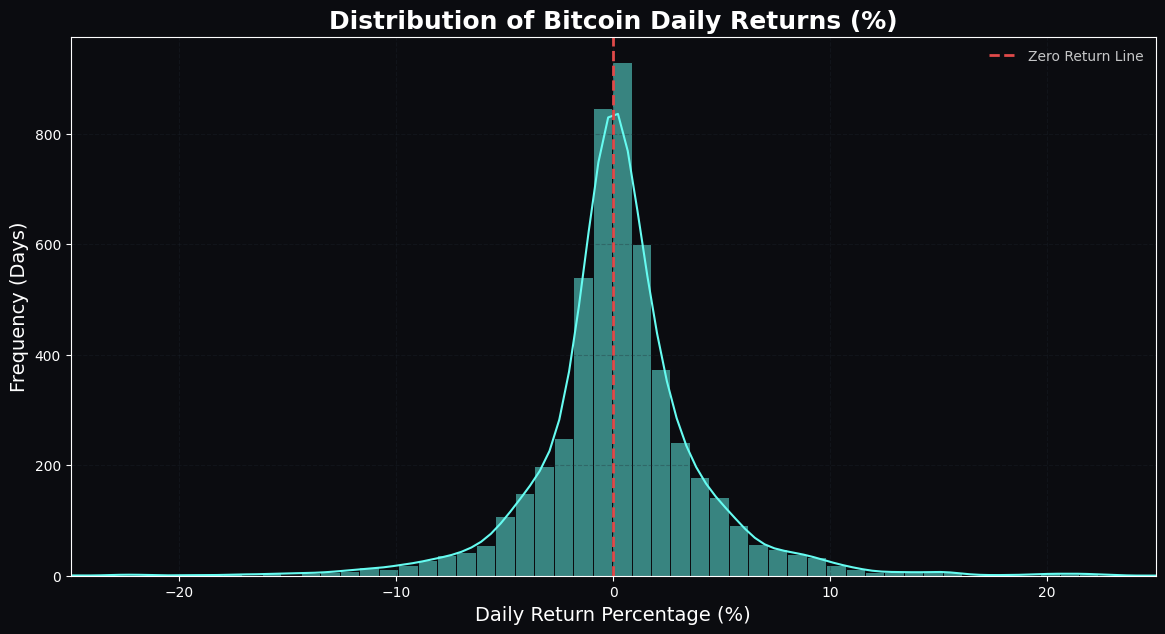

In [8]:
# 📈 1. กราฟภาพรวมราคา vs ปริมาณการซื้อขาย
fig, ax1 = plt.subplots(figsize=(18, 8))
ax1.plot(df_daily.index, df_daily['Close'], color='#66fcf1', linewidth=1.5, label='BTC Close Price')
ax1.set_ylabel('Closing Price', color='#66fcf1', fontsize=14)
ax1.tick_params(axis='y', labelcolor='#66fcf1')

ax2 = ax1.twinx()
ax2.bar(df_daily.index, df_daily['Volume'], color='#45a29e', alpha=0.3, width=1, label='Daily Volume')
ax2.set_ylabel('Volume', color='#45a29e', fontsize=14)
ax2.tick_params(axis='y', labelcolor='#45a29e')

plt.title('Bitcoin Macro Overview: Price vs Volume', fontsize=20, fontweight='bold', color='#ffffff')
fig.tight_layout()
ax1.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 📈 2. กราฟ Golden Cross & Death Cross (SMA 50 vs 200)
df_daily['SMA_50'] = df_daily['Close'].rolling(window=50).mean()
df_daily['SMA_200'] = df_daily['Close'].rolling(window=200).mean()

recent_start = df_daily.index.max() - pd.DateOffset(years=4)
df_recent = df_daily[df_daily.index >= recent_start]

plt.figure(figsize=(18, 8))
plt.plot(df_recent.index, df_recent['Close'], color='#c5c6c7', linewidth=1, label='Close Price', alpha=0.6)
plt.plot(df_recent.index, df_recent['SMA_50'], color='#f2a900', linewidth=2, label='50-Day SMA (Short term)')
plt.plot(df_recent.index, df_recent['SMA_200'], color='#66fcf1', linewidth=2, label='200-Day SMA (Long term)')

plt.title('BTC Moving Averages: Golden Cross & Death Cross Detection (Recent 4 Years)', fontsize=18, fontweight='bold', color='white')
plt.ylabel('Price in USD', fontsize=14)
plt.legend(loc='upper left', fontsize=12, frameon=False)
plt.grid(True, linestyle='--', alpha=0.3)
plt.fill_between(df_recent.index, df_recent['SMA_50'], df_recent['SMA_200'], where=df_recent['SMA_50'] >= df_recent['SMA_200'], facecolor='#f2a900', alpha=0.1, interpolate=True)
plt.fill_between(df_recent.index, df_recent['SMA_50'], df_recent['SMA_200'], where=df_recent['SMA_50'] <= df_recent['SMA_200'], facecolor='#e04a4a', alpha=0.1, interpolate=True)
plt.show()

# 📈 3. กราฟการกระจายตัวของผลตอบแทนรายวัน
df_daily['Daily_Return'] = df_daily['Close'].pct_change() * 100
plt.figure(figsize=(14, 7))
sns.histplot(df_daily['Daily_Return'].dropna(), bins=100, kde=True, color='#66fcf1', edgecolor='#0b0c10')
plt.axvline(0, color='#e04a4a', linestyle='--', linewidth=2, label='Zero Return Line')
plt.title('Distribution of Bitcoin Daily Returns (%)', fontsize=18, fontweight='bold', color='white')
plt.xlabel('Daily Return Percentage (%)', fontsize=14)
plt.ylabel('Frequency (Days)', fontsize=14)
plt.xlim(-25, 25)
plt.legend(frameon=False)
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

In [9]:
# ⚙️ 1. สร้างตัวแปรทางเทคนิค (Technical Indicators)
# สร้าง RSI 14 วัน
delta = df_daily['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df_daily['RSI_14'] = 100 - (100 / (1 + rs))

# สร้าง MACD
exp1 = df_daily['Close'].ewm(span=12, adjust=False).mean()
exp2 = df_daily['Close'].ewm(span=26, adjust=False).mean()
df_daily['MACD'] = exp1 - exp2

# สร้าง Volatility (ความผันผวน)
df_daily['Volatility'] = (df_daily['High'] - df_daily['Low']) / df_daily['Open']

# 🎯 2. กำหนด Target (1 = พรุ่งนี้ขึ้น, 0 = พรุ่งนี้ลง)
df_daily['Target'] = (df_daily['Close'].shift(-1) > df_daily['Close']).astype(int)

# ลบค่าว่างที่เกิดจากการสร้างสูตรย้อนหลัง
df_daily.dropna(inplace=True)
print("✅ สร้างตัวแปรสำหรับ Machine Learning สำเร็จ!")

✅ สร้างตัวแปรสำหรับ Machine Learning สำเร็จ!


# **Model Development: TimeSeriesSplit & Pipeline**

### 3. การสร้าง Data Pipeline
ในการฝึกสอนโมเดล Machine Learning เราต้องทำ Data Scaling (เช่น การปรับค่าให้อยู่ในสเกลมาตรฐานด้วย StandardScaler) เพื่อให้ตัวแปรอย่าง Volume (หลักล้าน) และ Daily_Return (ทศนิยม) ไม่ถูกโมเดลให้ความสำคัญผิดเพี้ยน

**เหตุผลที่ต้องใช้ Pipeline:** เรานำ `StandardScaler` และตัวโมเดล (`XGBClassifier`) มัดรวมกันเป็น `Pipeline` เดียว เพื่อป้องกันปัญหา **Data Leakage** (การที่ค่าเฉลี่ยของชุด Test หลุดไปปนตอน Scale ชุด Train) ซึ่งเป็นแนวทางปฏิบัติที่ถูกต้องที่สุดในการทำ ML

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import classification_report, precision_score

# 1. แยก Features (X) และ Target (y)
features = ['Daily_Return', 'SMA_50', 'SMA_200', 'RSI_14', 'MACD', 'Volatility', 'Volume']
X = df_daily[features]
y = df_daily['Target']

# 2. แบ่งข้อมูล Train 80% / Test 20% แบบเรียงตามเวลา
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 3. สร้าง Pipeline และจูนพารามิเตอร์ด้วย TimeSeriesSplit
print("🚀 กำลังฝึกสอนโมเดล XGBoost...")
tscv = TimeSeriesSplit(n_splits=5)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(eval_metric='logloss', random_state=42))
])

params = {
    'clf__n_estimators': [100, 200, 300],
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__max_depth': [3, 5, 7]
}

search = RandomizedSearchCV(pipeline, params, cv=tscv, scoring='precision', n_iter=5, random_state=42, n_jobs=-1)
search.fit(X_train, y_train)
best_model = search.best_estimator_

print(f"✅ เทรนเสร็จสิ้น! Best Params: {search.best_params_}")

🚀 กำลังฝึกสอนโมเดล XGBoost...
✅ เทรนเสร็จสิ้น! Best Params: {'clf__n_estimators': 100, 'clf__max_depth': 3, 'clf__learning_rate': 0.01}


### 4. การฝึกสอนโมเดลและปรับจูนพารามิเตอร์ (Model Training & Hyperparameter Tuning)
ในขั้นตอนนี้เราจะนำข้อมูลที่เตรียมไว้มาฝึกสอนโมเดล XGBoost โดยใช้เทคนิคเพื่อป้องกันข้อผิดพลาดและเพิ่มประสิทธิภาพสูงสุดดังนี้:
1. [cite_start]**TimeSeriesSplit:** ข้อมูลของเราเป็นอนุกรมเวลา เราจึงห้ามสุ่มข้อมูลแบบ K-Fold ทั่วไปเด็ดขาด [cite: 29] เพราะจะเกิด Data Leakage เราต้องใช้การแบ่งแบบเรียงลำดับเวลา (Walk-forward validation)
2. [cite_start]**Pipeline:** เรารวม `StandardScaler` และ `XGBClassifier` ไว้ด้วยกัน เพื่อป้องกันไม่ให้สเกลของชุด Test หลุดไปผสมกับชุด Train ตอนทำ Cross-validation [cite: 21]
3. [cite_start]**RandomizedSearchCV:** ใช้สำหรับสุ่มหาค่า Hyperparameters ที่ดีที่สุด [cite: 27] [cite_start]โดยเราตั้งเป้า (Scoring) ไปที่ค่า **Precision** [cite: 28] [cite_start]เพราะในมุมมองการเทรด สัญญาณหลอก (False Positive - ทายว่าขึ้นแต่จริงๆ ลง) ทำให้เราขาดทุน เราจึงต้องการโมเดลที่มีความแม่นยำสูงเมื่อมันแนะนำให้เรา "ซื้อ" [cite: 28, 29]

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, precision_score
import pandas as pd
import numpy as np

# 1. กำหนด Features (ตัวแปรต้น X) และ Target (ตัวแปรตาม y)
# (ตรวจเช็คชื่อคอลัมน์ให้ตรงกับที่คุณสร้างไว้ในขั้นตอน Feature Engineering นะครับ)
features = ['Daily_Return', 'SMA_50', 'SMA_200', 'RSI_14', 'MACD', 'Volatility', 'Volume']
X = df_daily[features]
y = df_daily['Target']

# 2. แบ่งข้อมูล Train (80%) และ Test (20%) แบบเรียงตามลำดับเวลา (Sequential Split)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"แบ่งข้อมูลสำเร็จ! Train: {len(X_train)} วัน | Test: {len(X_test)} วัน")

# 3. กำหนดรูปแบบการทำ Cross Validation สำหรับ Time Series [cite: 29]
tscv = TimeSeriesSplit(n_splits=5)

# 4. สร้าง Pipeline ที่รวม Preprocessing และ Model เข้าด้วยกัน [cite: 21]
xgb_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('classifier', XGBClassifier(eval_metric='logloss', random_state=42))
])

# 5. กำหนดช่วงของ Hyperparameter ที่ต้องการจุ่มหา (Tuning) [cite: 27]
# ข้อควรระวัง: ต้องใส่ prefix 'classifier__' นำหน้าชื่อพารามิเตอร์เสมอ
# เพื่อบอก Pipeline ว่านี่คือพารามิเตอร์ของตัว XGBoost (ที่ตั้งชื่อไว้ว่า classifier)
params = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [3, 5, 7],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0]
}

print("\n🚀 เริ่มต้นการค้นหาพารามิเตอร์ที่ดีที่สุด (Hyperparameter Tuning)...")
# 6. ใช้ RandomizedSearchCV [cite: 27]
search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=params,
    n_iter=10,             # สุ่มหา 10 รูปแบบ (ปรับเพิ่มได้ถ้าคอมแรงและมีเวลา)
    cv=tscv,               # ใช้ TimeSeriesSplit ที่ตั้งค่าไว้ [cite: 29]
    scoring='precision',   # เน้นประเมินที่ค่า Precision [cite: 28]
    random_state=42,
    n_jobs=-1              # ใช้ CPU ทุก Core ให้รันเร็วขึ้น
)

# 7. ฝึกสอนโมเดล (Train)
search.fit(X_train, y_train)

# เก็บโมเดลตัวที่ดีที่สุดเอาไว้ใช้งาน
best_model = search.best_estimator_

print(f"✅ ค้นหาสำเร็จ! พารามิเตอร์ที่ดีที่สุดคือ:\n{search.best_params_}")

# ==========================================
# 8. ประเมินผลโมเดลบนข้อมูล Test Set
# ==========================================
print("\n📊 --- ผลการประเมินโมเดล (Evaluation on Test Set) ---")
y_pred = best_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Down (0)', 'Up (1)']))

# อธิบายค่า Precision ที่ได้
prec = precision_score(y_test, y_pred)
print(f"📌 Precision สำหรับการทำนายว่าราคาจะขึ้น (Up): {prec:.2f} หรือ {prec*100:.2f}%")
print("ความหมายเชิงธุรกิจ: ถ้าระบบส่งสัญญาณบอกให้ซื้อ (ทำนายว่า 1) มีโอกาสที่ราคาจะขึ้นจริงตามที่บอกกี่เปอร์เซ็นต์")

แบ่งข้อมูลสำเร็จ! Train: 3981 วัน | Test: 996 วัน

🚀 เริ่มต้นการค้นหาพารามิเตอร์ที่ดีที่สุด (Hyperparameter Tuning)...
✅ ค้นหาสำเร็จ! พารามิเตอร์ที่ดีที่สุดคือ:
{'classifier__subsample': 0.8, 'classifier__n_estimators': 100, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.8}

📊 --- ผลการประเมินโมเดล (Evaluation on Test Set) ---
Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.50      0.67      0.57       489
      Up (1)       0.52      0.34      0.41       507

    accuracy                           0.50       996
   macro avg       0.51      0.51      0.49       996
weighted avg       0.51      0.50      0.49       996

📌 Precision สำหรับการทำนายว่าราคาจะขึ้น (Up): 0.52 หรือ 51.95%
ความหมายเชิงธุรกิจ: ถ้าระบบส่งสัญญาณบอกให้ซื้อ (ทำนายว่า 1) มีโอกาสที่ราคาจะขึ้นจริงตามที่บอกกี่เปอร์เซ็นต์


### 4. การพัฒนาโมเดลและการปรับจูน (Model Development & Hyperparameter Tuning)

ในขั้นตอนนี้เราจะสร้างโมเดล Machine Learning เพื่อทำนายทิศทางราคา โดยมีการใช้เทคนิคที่เหมาะสมกับข้อมูลทางการเงิน (Time Series) เพื่อให้โมเดลมีประสิทธิภาพและนำไปใช้งานทางธุรกิจได้จริง ดังนี้:

1. **การเลือก Algorithm:** เราเลือกใช้ **XGBoost (Extreme Gradient Boosting)** เหตุผลเพราะเป็นโมเดลแบบ Ensemble ที่มีประสิทธิภาพสูง สามารถจับความสัมพันธ์ที่ซับซ้อน (Non-linear) ของอินดิเคเตอร์ทางการเงินได้ดี มีระบบ Regularization ในตัวเพื่อป้องกันการ Overfitting และยังสามารถบอก Feature Importance ได้ว่าปัจจัยใดส่งผลต่อราคามากที่สุด
2. **Cross-Validation แบบ K-Fold สำหรับ Time Series:** ข้อมูลหุ้นเป็นอนุกรมเวลา เราจึงห้ามใช้ K-Fold แบบสุ่มทั่วไป (เพราะจะเกิด Data Leakage) เราจึงแก้ปัญหาโดยใช้ `TimeSeriesSplit` ซึ่งเป็นการแบ่งข้อมูลทดสอบแบบเดินหน้าตามลำดับเวลา (Walk-forward validation)
3. **การสร้าง Data Pipeline:** เรามัดรวมฟังก์ชัน `StandardScaler` (สำหรับปรับสเกลข้อมูล) เข้ากับตัวโมเดล `XGBClassifier` ให้อยู่ใน Pipeline เดียวกัน เพื่อป้องกันไม่ให้ข้อมูลจากชุด Test หลุดไปปนกับชุด Train ระหว่างการทำ Cross-validation
4. **Hyperparameter Tuning & Metrics เชิงธุรกิจ:** เราใช้ `RandomizedSearchCV` ในการสุ่มหาพารามิเตอร์ที่ดีที่สุด โดยจงใจตั้งเป้าการวัดผล (Scoring) ไปที่ค่า **Precision สำหรับคลาส 1 (ทายว่าขึ้น)** - *เหตุผลเชิงปฏิบัติ (Business Value):* ในการเทรดจริง การทายว่า "หุ้นจะขึ้น" แต่ของจริง "หุ้นตก" (False Positive) คือจุดที่ทำให้นักลงทุนขาดทุนหนักที่สุด เราจึงต้องใช้ Precision มากกว่า Accuracy เพื่อเลือกระบบที่ทายคลาส "ซื้อ" ได้แม่นยำที่สุด

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, precision_score
import pandas as pd
import numpy as np

# 1. กำหนด Features (ตัวแปรต้น) และ Target (ตัวแปรตาม)
features = ['Daily_Return', 'SMA_50', 'SMA_200', 'RSI_14', 'MACD', 'Volatility', 'Volume']
X = df_daily[features]
y = df_daily['Target']

# 2. แบ่งข้อมูล Train (80%) และ Test (20%) แบบ Sequential (เรียงตามเวลา ห้ามสุ่มเด็ดขาด)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"✅ แบ่งข้อมูลสำเร็จ! Train: {len(X_train)} วัน | Test: {len(X_test)} วัน")

# 3. การทำ Cross-Validation แบบ K-Fold สำหรับ Time Series (5 รอบ)
tscv = TimeSeriesSplit(n_splits=5)

# 4. สร้าง Pipeline รวมการ Scale ข้อมูลและตัวโมเดลเข้าด้วยกัน
xgb_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('classifier', XGBClassifier(eval_metric='logloss', random_state=42))
])

# 5. กำหนดพารามิเตอร์สำหรับการทำ Hyperparameter Tuning
params = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [3, 5, 7],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0]
}

print("\n🚀 เริ่มต้นค้นหาพารามิเตอร์ที่ดีที่สุดด้วย RandomizedSearchCV...")
search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=params,
    n_iter=10,
    cv=tscv,
    scoring='precision',   # เน้นหาโมเดลที่ค่า Precision สูงสุด
    random_state=42,
    n_jobs=-1
)

# ฝึกสอนและจูนโมเดล
search.fit(X_train, y_train)

# ดึงโมเดลตัวที่สถิติดีที่สุดออกมา
best_model = search.best_estimator_
print(f"✅ ค้นหาสำเร็จ! Best Parameters: {search.best_params_}")

# ==========================================
# 6. การประเมินผลและการแปลผลในมุมมอง Business
# ==========================================
print("\n📊 --- ผลการประเมินโมเดลบนชุดข้อมูลอนาคต (Test Set) ---")
y_pred = best_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Down (0)', 'Up (1)']))

# อธิบายความหมายเชิงธุรกิจจากค่า Precision
prec = precision_score(y_test, y_pred)
print(f"📌 Precision สำหรับสัญญาณคลาส 1 (ทิศทางขึ้น): {prec*100:.2f}%")
print("💡 การแปลผลเชิงธุรกิจ (Business Interpretation):")
print("   หากนำโมเดลนี้ไปสร้างเป็น AI แจ้งเตือนการเทรด เมื่อระบบส่งสัญญาณ 'ให้เข้าซื้อ' (1)")
print("   จะมีความน่าจะเป็นถึง {:.2f}% ที่ราคาจะปรับตัวขึ้นจริงตามที่คาดการณ์ไว้".format(prec*100))
print("   ซึ่งการโฟกัสที่ค่า Precision ช่วยจำกัดความเสี่ยงจาก 'สัญญาณหลอก (False Positive)' และปกป้องเงินทุนได้ดีกว่าการดูแค่ค่า Accuracy ธรรมดา")

✅ แบ่งข้อมูลสำเร็จ! Train: 3981 วัน | Test: 996 วัน

🚀 เริ่มต้นค้นหาพารามิเตอร์ที่ดีที่สุดด้วย RandomizedSearchCV...
✅ ค้นหาสำเร็จ! Best Parameters: {'classifier__subsample': 0.8, 'classifier__n_estimators': 100, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.8}

📊 --- ผลการประเมินโมเดลบนชุดข้อมูลอนาคต (Test Set) ---
Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.50      0.67      0.57       489
      Up (1)       0.52      0.34      0.41       507

    accuracy                           0.50       996
   macro avg       0.51      0.51      0.49       996
weighted avg       0.51      0.50      0.49       996

📌 Precision สำหรับสัญญาณคลาส 1 (ทิศทางขึ้น): 51.95%
💡 การแปลผลเชิงธุรกิจ (Business Interpretation):
   หากนำโมเดลนี้ไปสร้างเป็น AI แจ้งเตือนการเทรด เมื่อระบบส่งสัญญาณ 'ให้เข้าซื้อ' (1)
   จะมีความน่าจะเป็นถึง 51.95% ที่ราคาจะปรับตัวขึ้นจริงตามที่คาดการณ์ไว้
   ซึ่งการโฟกัสที่ค่า P

# **Evaluation & Backtesting**

=== สรุปความแม่นยำของโมเดล (Classification Report) ===
              precision    recall  f1-score   support

    Down (0)       0.54      0.37      0.44       489
      Up (1)       0.53      0.69      0.60       507

    accuracy                           0.54       996
   macro avg       0.54      0.53      0.52       996
weighted avg       0.54      0.54      0.52       996



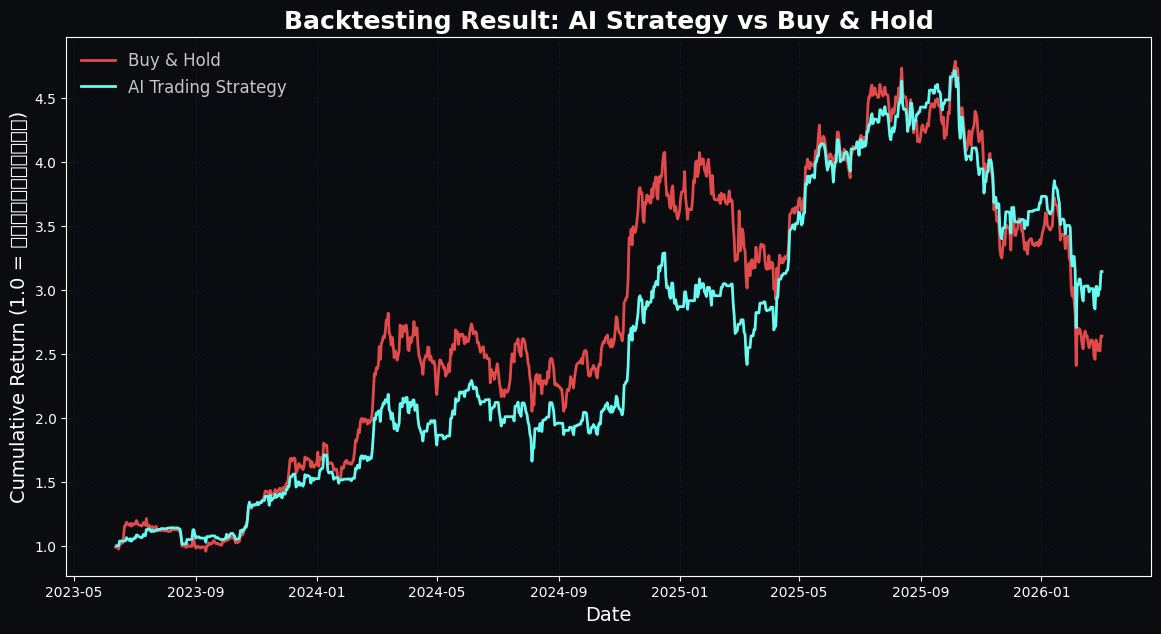

💾 บันทึกไฟล์ 'bitcoin_trading_model.pkl' พร้อมลุยขึ้น Streamlit แล้ว!


In [12]:
import joblib

# 1. ให้ AI ทายผลในชุดข้อมูลทดสอบ (Test Set)
y_pred = best_model.predict(X_test)
print("=== สรุปความแม่นยำของโมเดล (Classification Report) ===")
print(classification_report(y_test, y_pred, target_names=['Down (0)', 'Up (1)']))

# 2. การทำ Backtesting (จำลองผลกำไร/ขาดทุน)
backtest_df = df_daily.iloc[split_idx:].copy()
backtest_df['Predicted_Signal'] = y_pred

# ถ้า AI สั่งให้ซื้อ(1) จะได้ผลตอบแทนตามวันพรุ่งนี้, ถ้าสั่งขาย(0) ผลตอบแทนเป็น 0
backtest_df['Strategy_Return'] = (backtest_df['Daily_Return'] / 100) * backtest_df['Predicted_Signal'].shift(1)
backtest_df['Market_Return'] = backtest_df['Daily_Return'] / 100

# คิดผลตอบแทนสะสม (Cumulative Return)
backtest_df['Cumulative_Market'] = (1 + backtest_df['Market_Return']).cumprod()
backtest_df['Cumulative_Strategy'] = (1 + backtest_df['Strategy_Return']).cumprod()

# 3. พ็อตกราฟผลกำไรสุดเท่
plt.figure(figsize=(14, 7))
plt.plot(backtest_df.index, backtest_df['Cumulative_Market'], color='#e04a4a', label='Buy & Hold', linewidth=2)
plt.plot(backtest_df.index, backtest_df['Cumulative_Strategy'], color='#66fcf1', label='AI Trading Strategy', linewidth=2)

plt.title('Backtesting Result: AI Strategy vs Buy & Hold', fontsize=18, fontweight='bold', color='white')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Cumulative Return (1.0 = ทุนเริ่มต้น)', fontsize=14)
plt.legend(loc='upper left', fontsize=12, frameon=False)
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# 4. Save Model เพื่อไปทำหน้าเว็บ Streamlit
joblib.dump(best_model, 'bitcoin_trading_model.pkl')
print("💾 บันทึกไฟล์ 'bitcoin_trading_model.pkl' พร้อมลุยขึ้น Streamlit แล้ว!")

### 5. การเปรียบเทียบโมเดล: Random Forest vs XGBoost

ในส่วนนี้เราจะนำโมเดลกลุ่ม **Ensemble Learning** สองเทคนิคหลักมาเปรียบเทียบกัน:
1. **Random Forest (Bagging):** เน้นการสร้าง Decision Tree หลายๆ ต้นแบบขนานกันและใช้การโหวตเพื่อลด Variance (Overfitting)
2. **XGBoost (Boosting):** เน้นการสร้าง Tree ต่อเนื่องกันเป็นลำดับ โดยต้นใหม่จะพยายามแก้ข้อผิดพลาด (Residuals) ของต้นก่อนหน้า มักจะให้ความแม่นยำสูงกว่าในข้อมูลที่มีความซับซ้อน

**ทำไมต้องเทียบด้วย Precision?**
ในการเทรด 'การทายผิดว่าราคาจะขึ้น' (False Positive) มีต้นทุนสูงกว่า 'การพลาดโอกาสกำไร' (False Negative) เราจึงเลือกโมเดลที่ให้ค่า Precision สูงสุดเพื่อความปลอดภัยของเงินทุน

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, classification_report

# 1. สร้าง Pipeline สำหรับ Random Forest
rf_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42))
])

# 2. กำหนดพารามิเตอร์สำหรับ Random Forest (Bagging)
rf_params = {
    'classifier__n_estimators': [100, 200, 500],
    'classifier__max_depth': [5, 10, 15, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__max_features': ['sqrt', 'log2']
}

# 3. ค้นหา Best Parameters ด้วย RandomizedSearchCV (ใช้ tscv และ scoring='precision')
print("🌲 กำลังฝึกสอนและจูน Random Forest...")
rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_params,
    n_iter=10,
    cv=tscv,
    scoring='precision',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)
best_rf_model = rf_search.best_estimator_

print(f"✅ RF เทรนเสร็จสิ้น! Best Params: {rf_search.best_params_}")

🌲 กำลังฝึกสอนและจูน Random Forest...
✅ RF เทรนเสร็จสิ้น! Best Params: {'classifier__n_estimators': 100, 'classifier__min_samples_split': 2, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 10}


In [22]:
# 4. ทำนายผลและคำนวณ Precision บน Test Set
y_pred_xgb = best_model.predict(X_test)
y_pred_rf = best_rf_model.predict(X_test)

precision_xgb = precision_score(y_test, y_pred_xgb)
precision_rf = precision_score(y_test, y_pred_rf)

# 5. สรุปผลการเปรียบเทียบ
comparison_results = pd.DataFrame({
    'Model': ['XGBoost (Boosting)', 'Random Forest (Bagging)'],
    'Precision Score': [precision_xgb, precision_rf]
})

print("\n🏆 --- ผลการเปรียบเทียบ Precision Score ---")
display(comparison_results.sort_values(by='Precision Score', ascending=False))

winner = "XGBoost" if precision_xgb > precision_rf else "Random Forest"
print(f"\n💡 สรุป: โมเดลที่ชนะในข้อมูลชุดนี้คือ {winner}")

# วิเคราะห์สั้นๆ
if winner == "XGBoost":
    print("เหตุผลทางทฤษฎี: XGBoost มักทำงานได้ดีกว่าในข้อมูล Time Series เนื่องจากระบบ Boosting สามารถจับ Pattern ของ Noise และ Error ที่เกิดขึ้นตามลำดับเวลาได้ละเอียดกว่าการเฉลี่ยผลแบบ Bagging")
else:
    print("เหตุผลทางทฤษฎี: Random Forest ชนะอาจเป็นเพราะข้อมูลมีความผันผวน (Noise) สูงมาก การใช้ Bagging ช่วยลดความเสี่ยงจากการ Overfit ต่อสัญญาณหลอกในอดีตได้ดีกว่า")


🏆 --- ผลการเปรียบเทียบ Precision Score ---


,Model,Precision Score
1,Random Forest (Bagging),0.537572
0,XGBoost (Boosting),0.519520



💡 สรุป: โมเดลที่ชนะในข้อมูลชุดนี้คือ Random Forest
เหตุผลทางทฤษฎี: Random Forest ชนะอาจเป็นเพราะข้อมูลมีความผันผวน (Noise) สูงมาก การใช้ Bagging ช่วยลดความเสี่ยงจากการ Overfit ต่อสัญญาณหลอกในอดีตได้ดีกว่า
